This script is to apply the baseline model from Eid et al. to our EVAAV dataset. I believe that the LSTM might actually be an overkill especially since we have only about 2000 good datapoints that probably contain a considerable amount of noise themselves.

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
os.environ['KERAS_BACKEND'] = 'tensorflow'
from keras.models import Sequential
from keras.layers import Dense, LSTM, Flatten, Conv2D
from sklearn.model_selection import KFold
from HyperparameterTuningLSTMUtils import AA_hotencoding
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold

2026-05-11 19:08:18.839999: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-11 19:08:18.852186: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778522898.865917   86625 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778522898.870012   86625 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-11 19:08:18.884021: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
# Set font type to Arial
plt.rcParams['font.family'] = 'Arial'

In [3]:
def LongShortTermMemoryModel(L1=160, L2=20):
    
    """
    
    parent_model builds an LSTM model with paramters that work accross all functional fitness models in the Fit4Function study. 
    L1 and L2 define the sizes of the model two layers. 
    
    """
    model = Sequential()
    model.add(LSTM(L1, return_sequences=True, input_shape=(8, 20)))
    model.add(LSTM(L2, return_sequences=False))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

    return model

def Perceptron(L1=160):

    model = Sequential()
    model.add(Flatten(input_shape=(8, 20)))
    model.add(Dense(L1))
    model.add(Dense(L1))
    model.add(Dense(units=1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
    return model

def CNN(L1=160):
    model = Sequential()
    # Add a Conv2D layer with filters that convolve along the height (8) while preserving the width (20)
    model.add(Conv2D(L1, (8, 1), activation='relu', input_shape=(8, 20, 1)))
    # Flatten the output to feed into Dense layers
    model.add(Flatten())
    # Output layer with a single unit for continuous output
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])
    return model

In [ ]:
# Starting from read count to perform ablation study

# define numerator and denominator files to calculate enrichment
df_numerator = pd.read_excel("data/Excel/third_round/pre_encapsulation_variant_count.xlsx")
df_denominator = pd.read_excel("data/Excel/third_round/post_encapsulation_variant_count.xlsx")

display(df_numerator.head())

,ID,variant,quality,variant_length,variant_count
0,V350230572L2C003R05800976762/1,CTGCGTGGTGATGTTGGGGGGCCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,7544
1,V350231704L3C001R03000327567/1,AGTAGAGACGCGTAGGGATCCCGTCTCGGGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",31,7541
2,V350230572L1C001R04900519270/1,TTGTCGGATCGTAAGTTTGAACGGCAGGCTAATGTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,1539
3,V350231704L3C003R01100128026/1,CTGAGTGGGAGGCTGGATATTCTGCCTAAGCTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1427
4,V350231704L3C001R02300983205/1,TTGTTTGATCGGCTGGATGTTCTGTCGAGTGGTGCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1141


In [5]:
# Calculate the sum of all integers in the column "variant_count"
total_variant_count_denominator = df_denominator['variant_count'].sum()
total_variant_count_numerator = df_numerator['variant_count'].sum()

# merging both dataframes
merged_df = pd.merge(df_denominator, df_numerator, on='variant', suffixes=('_denominator', '_numerator'))
display(merged_df.head())

,ID_denominator,variant,quality_denominator,variant_length_denominator,variant_count_denominator,ID_numerator,quality_numerator,variant_length_numerator,variant_count_numerator
0,V350230572L1C003R04900669874/1,CTGCGTGGTGATGTTGGGGGGCCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,58563,V350230572L2C003R05800976762/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,7544
1,V350230572L2C005R01800167223/1,TTGTCGGATCGTAAGTTTGAACGGCAGGCTAATGTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,17385,V350230572L1C001R04900519270/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",39,1539
2,V350230572L2C004R03100753574/1,CTGAGTGGGAGGCTGGATATTCTGCCTAAGCTTTTT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,14307,V350231704L3C003R01100128026/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1427
3,V350230572L1C003R05500568788/1,TTGTTTGATCGGCTGGATGTTCTGTCGAGTGGTGCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,5328,V350231704L3C001R02300983205/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",36,1141
4,V350230572L1C002R04701161624/1,AGTAGAGACGCGTAGGGATCCCGTCTCGGGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",31,5036,V350231704L3C001R03000327567/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",31,7541


In [6]:
# Introduce read count cutoff
merged_df = merged_df.loc[merged_df["variant_count_denominator"] >= 32]
merged_df = merged_df.loc[merged_df["variant_count_numerator"] >= 32]

# Normalize the "variant_count" columns
merged_df[f'variant_count_denominator_normalized'] = merged_df[f"variant_count_denominator"] / total_variant_count_denominator
merged_df[f'variant_count_numerator_normalized'] = merged_df[f"variant_count_numerator"] / total_variant_count_numerator

# Create a new column for the division result
merged_df[f'enrichment_score'] = merged_df[f'variant_count_numerator_normalized'] / merged_df[f'variant_count_denominator_normalized']

# log2 transform the enrichment score for each read count divisor
merged_df[f'log2_enrichment_score'] = merged_df[f'enrichment_score'].apply(lambda x: np.log2(x))

from Bio.Seq import Seq

# Function to translate DNA sequence to amino acid sequence
def translate_dna_to_protein(dna_seq):
    dna_seq_obj = Seq(dna_seq)
    protein_seq = str(dna_seq_obj.translate())
    return protein_seq

# Translate the 'variant' column and save in a new column 'amino_acid_sequence'
merged_df['amino_acid_sequence'] = merged_df['variant'].apply(translate_dna_to_protein)

# Get rid of variants with stop codons and filter for length 24
merged_df = merged_df[~merged_df.astype(str).apply(lambda row: row.str.contains(r"\*").any(), axis=1)]
merged_df = merged_df.loc[merged_df["variant_length_denominator"]==24]

# Remove rational designs from the dataset
rational_motifs = ["YP*L", "PP*Y", "FPIV", "PLPPV", "L**L", "KFERQ", "PSAP", "PTAP"]

import re

# Function to check if sequence contains any of the motifs
def contains_motifs(sequence, motifs):
    return any(motif for motif in motifs if contains_wildcard_motif(sequence, motif))

def contains_wildcard_motif(sequence, motif):
    # Convert the motif to a regex pattern, replacing '*' with '.'
    regex_pattern = motif.replace("*", ".")
    # Search for the pattern in the sequence
    return re.search(regex_pattern, sequence) is not None

merged_df = merged_df[~merged_df['amino_acid_sequence'].apply(lambda seq: contains_motifs(seq, rational_motifs))]

display(merged_df.head())


/home/marinaluchner/anaconda3/envs/learningenv/lib/python3.12/site-packages/Bio/Seq.py:2879: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


,ID_denominator,variant,quality_denominator,variant_length_denominator,variant_count_denominator,ID_numerator,quality_numerator,variant_length_numerator,variant_count_numerator,variant_count_denominator_normalized,variant_count_numerator_normalized,enrichment_score,log2_enrichment_score,amino_acid_sequence
0,V350230572L1C003R04900669874/1,CTGCGTGGTGATGTTGGGGGGCCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,58563,V350230572L2C003R05800976762/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,7544,0.013518,0.001544,0.114206,-3.130292,LRGDVGGP
5,V350230572L1C004R05700108921/1,AGGCGGGCGGATACTTGTAGTGCG,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,4796,V350230572L1C001R04800561978/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,696,0.001107,0.000142,0.128659,-2.958377,RRADTCSA
6,V350230572L2C003R03701213307/1,CATAAGGAGCATTGTGCTACGAGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,4449,V350231704L3C003R02301264686/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,543,0.001027,0.000111,0.108205,-3.208161,HKEHCATS
8,V350230572L1C002R07100567629/1,ACTGCGCCTGGGGTTCATTGTGGT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,3297,V350230572L1C001R04201058623/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,733,0.000761,0.000150,0.197104,-2.342973,TAPGVHCG
10,V350230572L2C004R02300026454/1,AGGTGTGTTGATCAGAAGGTTTCT,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,3172,V350231704L3C002R00501383900/1,"[93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 93, 9...",24,389,0.000732,0.000080,0.108724,-3.201255,RCVDQKVS


In [7]:
datapoint_divisors = [1, 20, 40, 60, 80, 100]

models = {}

for datapoint_divisor in datapoint_divisors:

    # GOAL train test split
    # 80% training, 10% validation, 10% test
    train_size = int(0.8 * len(merged_df)/datapoint_divisor)
    test_size = int(0.2 * len(merged_df))
    print(f"Datapoint divisor: {datapoint_divisor}, Total samples: {len(merged_df)}, Train size: {train_size}, Test size: {test_size}")

    # Split the data into training and test sets
    train, test = np.split(merged_df.sample(frac=1), [train_size])

    # GOAL one hot encoding of the amino acid sequences
    train_x = np.asarray([AA_hotencoding(variant) for variant in train["amino_acid_sequence"]])
    train_y = np.asarray([score for score in train[f'log2_enrichment_score']])
    test_x = np.asarray([AA_hotencoding(variant) for variant in test["amino_acid_sequence"]])
    test_y = np.asarray([score for score in test[f'log2_enrichment_score']])

    models[f'FNN_{datapoint_divisor}'] = [Perceptron, datapoint_divisor, train_x, train_y, test_x, test_y]
    models[f'LSTM_{datapoint_divisor}'] = [LongShortTermMemoryModel, datapoint_divisor, train_x, train_y, test_x, test_y]
    models[f'CNN_{datapoint_divisor}'] = [CNN, datapoint_divisor, train_x, train_y, test_x, test_y]

Datapoint divisor: 1, Total samples: 1835, Train size: 1468, Test size: 367
Datapoint divisor: 20, Total samples: 1835, Train size: 73, Test size: 367
Datapoint divisor: 40, Total samples: 1835, Train size: 36, Test size: 367
Datapoint divisor: 60, Total samples: 1835, Train size: 24, Test size: 367
Datapoint divisor: 80, Total samples: 1835, Train size: 18, Test size: 367
Datapoint divisor: 100, Total samples: 1835, Train size: 14, Test size: 367


/home/marinaluchner/anaconda3/envs/learningenv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [8]:
pearson_results = {model_name: [] for model_name in models.keys()}

In [9]:
# Define the number of folds
kf = KFold(n_splits=10, shuffle=True, random_state=32)

In [10]:
for model_name, model_params in models.items():
    model_func = model_params[0]
    datapoint_divisor = model_params[1]
    train_x = model_params[2]
    train_y = model_params[3]
    test_x = model_params[4]
    test_y = model_params[5]

    fold = 1
    fold_results = []

    for train_index, val_index in kf.split(train_x):
        
        print(f"Training fold {fold} for {model_name}...")
        
        # Split the data into training and validation sets
        X_train, X_val = train_x[train_index], train_x[val_index]
        y_train, y_val = train_y[train_index], train_y[val_index]

        # Create the model
        model = model_func()
        
        # Train the model
        model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=50,
            batch_size=500,
            verbose=0
        )

        # Store the results for the current model
        y_pred = model.predict(test_x)
        y_pred = np.reshape(y_pred, (1,y_pred.shape[0]))[0]
        pearson_corr = np.corrcoef(test_y, y_pred)[0, 1]
        pearson_results[model_name].append(pearson_corr)
        print(f"Pearson for {model_name} {fold}: {pearson_results[model_name]}")
        
        fold += 1

Training fold 1 for FNN_1...


/home/marinaluchner/anaconda3/envs/learningenv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
W0000 00:00:1778522985.594765   86625 gpu_device.cc:2344] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Pearson for FNN_1 1: [0.6406177940096612]
Training fold 2 for FNN_1...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Pearson for FNN_1 2: [0.6406177940096612, 0.6319992064323461]
Training fold 3 for FNN_1...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Pearson for FNN_1 3: [0.6406177940096612, 0.6319992064323461, 0.6504784718273517]
Training fold 4 for FNN_1...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Pearson for FNN_1 4: [0.6406177940096612, 0.6319992064323461, 0.6504784718273517, 0.6547486941406563]
Training fold 5 for FNN_1...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Pearson for FNN_1 5: [0.6406177940096612, 0.6319992064323461, 0.6504784718273517, 0.6547486941406563, 0.6555950403075281]
Training fold 6 for FNN_1...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Pearson for FNN_1 6: [0.6406177940096612, 0.6319992064323461, 0.6504784718273517, 0.6547486941406563, 0.6555950403075281, 0.6446530581836167]
Training fold 7 for FNN_1...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/

/home/marinaluchner/anaconda3/envs/learningenv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
Pearson for LSTM_1 1: [0.7180790634434407]
Training fold 2 for LSTM_1...
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
Pearson for LSTM_1 2: [0.7180790634434407, 0.7080035381396859]
Training fold 3 for LSTM_1...
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
Pearson for LSTM_1 3: [0.7180790634434407, 0.7080035381396859, 0.7217335582605338]
Training fold 4 for LSTM_1...
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
Pearson for LSTM_1 4: [0.7180790634434407, 0.7080035381396859, 0.7217335582605338, 0.7255821018408053]
Training fold 5 for LSTM_1...
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
Pearson for LSTM_1 5: [0.7180790634434407, 0.7080035381396859, 0.7217335582605338, 0.7255821018408053, 0.7207329586805147]
Training fold 6 for LSTM_1...
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
Pearson for LSTM_1 6: [0.7180790634434407, 0.7080035381396859, 0.7217335582605338, 0.7255821018408053, 0.7207329586805147, 0.6831098425598067]
Training fold 7 for LSTM_1...
12/12 ━━━━━━━━━━━━━━━━

/home/marinaluchner/anaconda3/envs/learningenv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Pearson for CNN_1 1: [0.6711468982771419]
Training fold 2 for CNN_1...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Pearson for CNN_1 2: [0.6711468982771419, 0.6755440372786465]
Training fold 3 for CNN_1...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Pearson for CNN_1 3: [0.6711468982771419, 0.6755440372786465, 0.6887147099084217]
Training fold 4 for CNN_1...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Pearson for CNN_1 4: [0.6711468982771419, 0.6755440372786465, 0.6887147099084217, 0.682843738872186]
Training fold 5 for CNN_1...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Pearson for CNN_1 5: [0.6711468982771419, 0.6755440372786465, 0.6887147099084217, 0.682843738872186, 0.6865396630775614]
Training fold 6 for CNN_1...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Pearson for CNN_1 6: [0.6711468982771419, 0.6755440372786465, 0.6887147099084217, 0.682843738872186, 0.6865396630775614, 0.673931179803883]
Training fold 7 for CNN_1...
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

In [11]:
kf = KFold(n_splits=10, shuffle=True, random_state=80)

for datapoint_divisor in datapoint_divisors:

    # GOAL train test split
    # 80% training, 10% validation, 10% test
    train_size = int(0.8 * len(merged_df)/datapoint_divisor)
    test_size = int(0.2 * len(merged_df))
    print(f"Datapoint divisor: {datapoint_divisor}, Total samples: {len(merged_df)}, Train size: {train_size}, Test size: {test_size}")

    # Split the data into training and test sets
    train, test = np.split(merged_df.sample(frac=1), [train_size])

    # GOAL one hot encoding of the amino acid sequences
    train_x = np.asarray([AA_hotencoding(variant) for variant in train["amino_acid_sequence"]])
    train_y = np.asarray([score for score in train[f'log2_enrichment_score']])
    test_x = np.asarray([AA_hotencoding(variant) for variant in test["amino_acid_sequence"]])
    test_y = np.asarray([score for score in test[f'log2_enrichment_score']])

    fold_results = []
    fold = 1

    for train_index, val_index in kf.split(train_x):
        print(f"Training fold {fold}...")
        
        # Split the data into training and validation sets
        X_train, discard = train_x[train_index], train_x[val_index]
        y_train, discard = train_y[train_index], train_y[val_index]

        # Reshape the 3D arrays into 2D arrays
        X_train_reshaped = X_train.reshape(X_train.shape[0], -1)
        X_test_reshaped = test_x.reshape(test_x.shape[0], -1)
        
        # Train the model
        model = LinearRegression()
        model.fit(X_train_reshaped, y_train)
        y_pred = model.predict(X_test_reshaped)

        # Calculate pearson correlation coefficient
        corrcoef = np.corrcoef(test_y, y_pred)[0, 1]
        # Append the results to the fold_results list
        fold_results.append(corrcoef)
        print(f"Pearson for LR_{datapoint_divisor}_{fold}: {corrcoef}")
        fold += 1

    pearson_results[f'LR_{datapoint_divisor}'] = fold_results

Datapoint divisor: 1, Total samples: 1835, Train size: 1468, Test size: 367
Training fold 1...
Pearson for LR_1_1: 0.5960735813256481
Training fold 2...
Pearson for LR_1_2: 0.5931106073825263
Training fold 3...
Pearson for LR_1_3: 0.5998706595839007
Training fold 4...
Pearson for LR_1_4: 0.6011219582082109
Training fold 5...
Pearson for LR_1_5: 0.602126793883915
Training fold 6...
Pearson for LR_1_6: 0.5976421737045936
Training fold 7...
Pearson for LR_1_7: 0.5836772160288504
Training fold 8...
Pearson for LR_1_8: 0.6006667329860316
Training fold 9...
Pearson for LR_1_9: 0.590528901255723
Training fold 10...
Pearson for LR_1_10: 0.5954957261129412
Datapoint divisor: 20, Total samples: 1835, Train size: 73, Test size: 367
Training fold 1...


/home/marinaluchner/anaconda3/envs/learningenv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Pearson for LR_20_1: 0.3899193648711255
Training fold 2...
Pearson for LR_20_2: 0.37922396351106374
Training fold 3...
Pearson for LR_20_3: 0.3759729880842776
Training fold 4...
Pearson for LR_20_4: 0.3644728486698239
Training fold 5...
Pearson for LR_20_5: 0.39964246410875465
Training fold 6...
Pearson for LR_20_6: 0.35473410253126936
Training fold 7...
Pearson for LR_20_7: 0.3169658429504798
Training fold 8...
Pearson for LR_20_8: 0.3544480172486863
Training fold 9...
Pearson for LR_20_9: 0.3355239273167934
Training fold 10...
Pearson for LR_20_10: 0.3623400495506577
Datapoint divisor: 40, Total samples: 1835, Train size: 36, Test size: 367
Training fold 1...


/home/marinaluchner/anaconda3/envs/learningenv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/home/marinaluchner/anaconda3/envs/learningenv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Pearson for LR_40_1: 0.30024165190183083
Training fold 2...
Pearson for LR_40_2: 0.29499723255392973
Training fold 3...
Pearson for LR_40_3: 0.26647292295388886
Training fold 4...
Pearson for LR_40_4: 0.3145699429149169
Training fold 5...
Pearson for LR_40_5: 0.29251822457335647
Training fold 6...
Pearson for LR_40_6: 0.30399511031234533
Training fold 7...
Pearson for LR_40_7: 0.2919905542351697
Training fold 8...
Pearson for LR_40_8: 0.2849468139191499
Training fold 9...
Pearson for LR_40_9: 0.305911535828016
Training fold 10...
Pearson for LR_40_10: 0.3070369618555592
Datapoint divisor: 60, Total samples: 1835, Train size: 24, Test size: 367
Training fold 1...
Pearson for LR_60_1: 0.21317217859630502
Training fold 2...
Pearson for LR_60_2: 0.21923906392962966
Training fold 3...
Pearson for LR_60_3: 0.18582520321170926
Training fold 4...
Pearson for LR_60_4: 0.2010321207930816
Training fold 5...
Pearson for LR_60_5: 0.20159660906890983
Training fold 6...
Pearson for LR_60_6: 0.1471308

/home/marinaluchner/anaconda3/envs/learningenv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)
/home/marinaluchner/anaconda3/envs/learningenv/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Pearson for LR_80_7: 0.1639921793148835
Training fold 8...
Pearson for LR_80_8: 0.20979832948325416
Training fold 9...
Pearson for LR_80_9: 0.2167137767978142
Training fold 10...
Pearson for LR_80_10: 0.2183517135706752
Datapoint divisor: 100, Total samples: 1835, Train size: 14, Test size: 367
Training fold 1...
Pearson for LR_100_1: 0.12724786650113495
Training fold 2...
Pearson for LR_100_2: -0.015385092965718926
Training fold 3...
Pearson for LR_100_3: 0.10291071674418316
Training fold 4...
Pearson for LR_100_4: 0.1543824170931539
Training fold 5...
Pearson for LR_100_5: 0.14073050672346182
Training fold 6...
Pearson for LR_100_6: 0.13584828277262048
Training fold 7...
Pearson for LR_100_7: 0.18798954272824245
Training fold 8...
Pearson for LR_100_8: 0.16564576587680868
Training fold 9...
Pearson for LR_100_9: 0.09183173823097349
Training fold 10...
Pearson for LR_100_10: 0.08064083216483715


In [12]:
print(pearson_results)

{'FNN_1': [0.6406177940096612, 0.6319992064323461, 0.6504784718273517, 0.6547486941406563, 0.6555950403075281, 0.6446530581836167, 0.6463252140233186, 0.6432902197109153, 0.6419327634609435, 0.654841819133943], 'LSTM_1': [0.7180790634434407, 0.7080035381396859, 0.7217335582605338, 0.7255821018408053, 0.7207329586805147, 0.6831098425598067, 0.7041499904973092, 0.7162499138254229, 0.7178562480203392, 0.7243326345564872], 'CNN_1': [0.6711468982771419, 0.6755440372786465, 0.6887147099084217, 0.682843738872186, 0.6865396630775614, 0.673931179803883, 0.6840028220284773, 0.6837680274887074, 0.6788167779001989, 0.6911345712013006], 'FNN_20': [0.2068049940290548, 0.24527333709624, 0.23014226839416105, 0.2666803857130298, 0.1965507723839008, 0.15266148476914196, 0.19264386458910338, 0.18756406676914816, 0.20008881642399437, 0.15103326421429006], 'LSTM_20': [0.22144372755146552, 0.33888714389382757, 0.3586496591807352, 0.26500659922164177, 0.26592383876845616, 0.272244749869778, 0.227231193840428

In [13]:
# Set font properties
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 24

In [14]:
from statistics import mean

averages = {
    key: mean(values)
    for key, values in pearson_results.items()
}
errors = {
    key: np.std(values)
    for key, values in pearson_results.items()
}

print(averages)

from collections import defaultdict

model_results = defaultdict(list)

model_errors = defaultdict(list)

for key, avg in averages.items():
    model, threshold = key.split("_")
    model_results[model].append((threshold, avg))

for key, error in errors.items():
    model, threshold = key.split("_")
    model_errors[model].append((threshold, error))

print(model_results)

final = {}
final_errors = {}

for model, values in model_results.items():
    values.sort(key=lambda x: x[0])        # sort by threshold
    final[model] = [avg for _, avg in values]

for model, values in model_errors.items():
    values.sort(key=lambda x: x[0])        # sort by threshold
    final_errors[model] = [error for _, error in values]

final_lists = {k: [v for v in vals] for k, vals in final.items()}
final_error_lists = {k: [v for v in vals] for k, vals in final_errors.items()}

print(final_lists)

{'FNN_1': 0.646448228123028, 'LSTM_1': 0.7139829849824345, 'CNN_1': 0.6816442425836524, 'FNN_20': 0.20294432543820645, 'LSTM_20': 0.27164615215050114, 'CNN_20': 0.37038131768043003, 'FNN_40': 0.23127973150088146, 'LSTM_40': 0.2698434727119976, 'CNN_40': 0.3823005807494581, 'FNN_60': 0.08817540133610764, 'LSTM_60': 0.2897160207775857, 'CNN_60': 0.21627752457562607, 'FNN_80': -0.030162914055540894, 'LSTM_80': -0.1655127491480177, 'CNN_80': 0.025756235077271712, 'FNN_100': 0.02747607187330341, 'LSTM_100': 0.2814494851668101, 'CNN_100': 0.130372877458053, 'LR_1': 0.5960314350472341, 'LR_20': 0.3633243568842932, 'LR_40': 0.2962680951048163, 'LR_60': 0.19786423539638776, 'LR_80': 0.20873887897065121, 'LR_100': 0.11718425758696971}
defaultdict(<class 'list'>, {'FNN': [('1', 0.646448228123028), ('20', 0.20294432543820645), ('40', 0.23127973150088146), ('60', 0.08817540133610764), ('80', -0.030162914055540894), ('100', 0.02747607187330341)], 'LSTM': [('1', 0.7139829849824345), ('20', 0.27164615

[0.5960314350472341, 0.11718425758696971, 0.3633243568842932, 0.2962680951048163, 0.19786423539638776, 0.20873887897065121]
[0.646448228123028, 0.02747607187330341, 0.20294432543820645, 0.23127973150088146, 0.08817540133610764, -0.030162914055540894]
[0.6816442425836524, 0.130372877458053, 0.37038131768043003, 0.3823005807494581, 0.21627752457562607, 0.025756235077271712]
[0.7139829849824345, 0.2814494851668101, 0.27164615215050114, 0.2698434727119976, 0.2897160207775857, -0.1655127491480177]


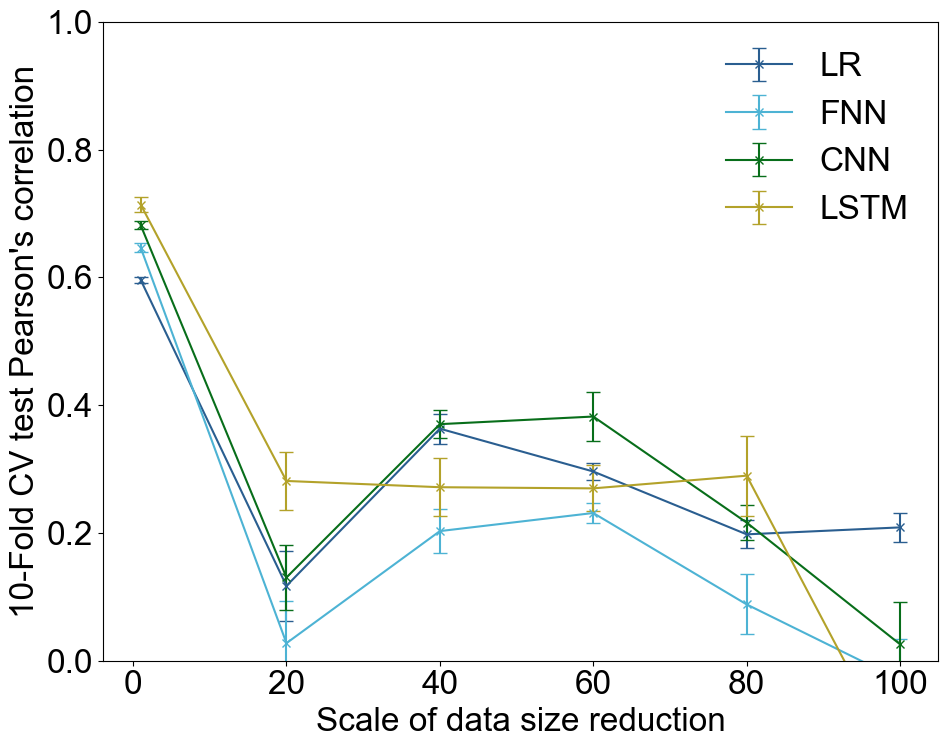

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# Paul Tol's Notes color scheme
colors = ['#4477AA','#66CCEE','#228833','#CCBB44','#EE6677','#AA3377','#BBBBBB']

# Function to darken a color
def darken_color(color, amount=0.1):
    c = mcolors.to_rgb(color)
    return mcolors.to_hex([max(0, c[i] - amount) for i in range(3)])

darker_colors = [darken_color(color) for color in colors]

# Create scatter plot

plt.figure(figsize=(10, 8))

j = 0

# Desired order of models
model_order = ["LR", "FNN", "CNN", "LSTM"]

# Plot average Pearson correlation coefficients
for model_name in model_order:
    print(final_lists[model_name])
    plt.errorbar(
        datapoint_divisors, 
        final_lists[model_name], 
        yerr=final_error_lists[model_name],
        capsize=5, 
        color=darker_colors[j], 
        marker='x',  
        label=f'{model_name}'
    )
    j += 1

# Customize plot
plt.ylabel("10-Fold CV test Pearson's correlation", fontsize=24)
plt.xlabel('Scale of data size reduction', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.ylim(0, 1)

# Create custom legend
handles = [
    plt.Line2D([0], [0], marker='o', color='black', markerfacecolor='black', markersize=7, label='Individual'),
    plt.Line2D([0], [0], marker='x', color='black', markersize=7, label='Average')
]

plt.legend(frameon=False)

# Show plot
plt.tight_layout()
plt.show()